# FinIntel Fraud Detection Analysis and Model Selection

This notebook documents the fraud-detection workflow used in FinIntel, including EDA, behavioural feature understanding, preprocessing, comparative model evaluation, and the justification for the final XGBoost-based fraud classifier.

## 1. Setup

In [ ]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns 
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    SMOTE = None

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

PROJECT_ROOT = Path(r'E:/FraudPulse')
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORT_ASSET_DIR = PROJECT_ROOT / 'docs' / 'generated_report_diagrams'
REPORT_ASSET_DIR.mkdir(parents=True, exist_ok=True)

fraud_path = PROCESSED_DIR / 'fraud_dataset_v2.csv'
fraud_df = pd.read_csv(fraud_path)
fraud_df.shape

(70000, 27)

## 2. Dataset Overview

In [2]:
summary = pd.DataFrame(
    {
        'Rows': [len(fraud_df)],
        'Columns': [fraud_df.shape[1]],
        'Fraud Cases': [int(fraud_df['is_fraud'].sum())],
        'Legitimate Cases': [int((fraud_df['is_fraud'] == 0).sum())],
    }
)
summary

,Rows,Columns,Fraud Cases,Legitimate Cases
0,70000,27,12600,57400


In [3]:
fraud_df.head()

,age,account_type,city_tier,tenure_days,account_balance,avg_monthly_spend,avg_txn_amount,avg_txn_per_day,usual_txn_hour,txn_type,...,velocity_24hr,new_txn_type_flag,large_round_amt_flag,days_since_last_txn,prior_fraud_complaint,fraud_type,is_fraud,account_type_enc,txn_type_enc,age_group
0,32,Savings,1,4924,50962,12306,839,3,9,NEFT,...,2,0,0,2,0,NaN,0,2,5,26-40
1,52,Salary,1,3961,167688,50148,3120,1,8,IMPS,...,3,0,0,0,0,NaN,0,1,4,41-60
2,65,Current,2,346,174684,56926,9083,1,11,CASH_OUT,...,1,0,0,0,0,NaN,0,0,2,60+
3,40,Savings,3,1714,179126,60082,13555,3,8,UPI,...,2,0,0,0,0,NaN,0,2,6,26-40
4,45,Savings,2,212,24335,6313,623,3,16,CASH_OUT,...,2,0,0,0,0,NaN,0,2,2,41-60


## 3. Exploratory Data Analysis

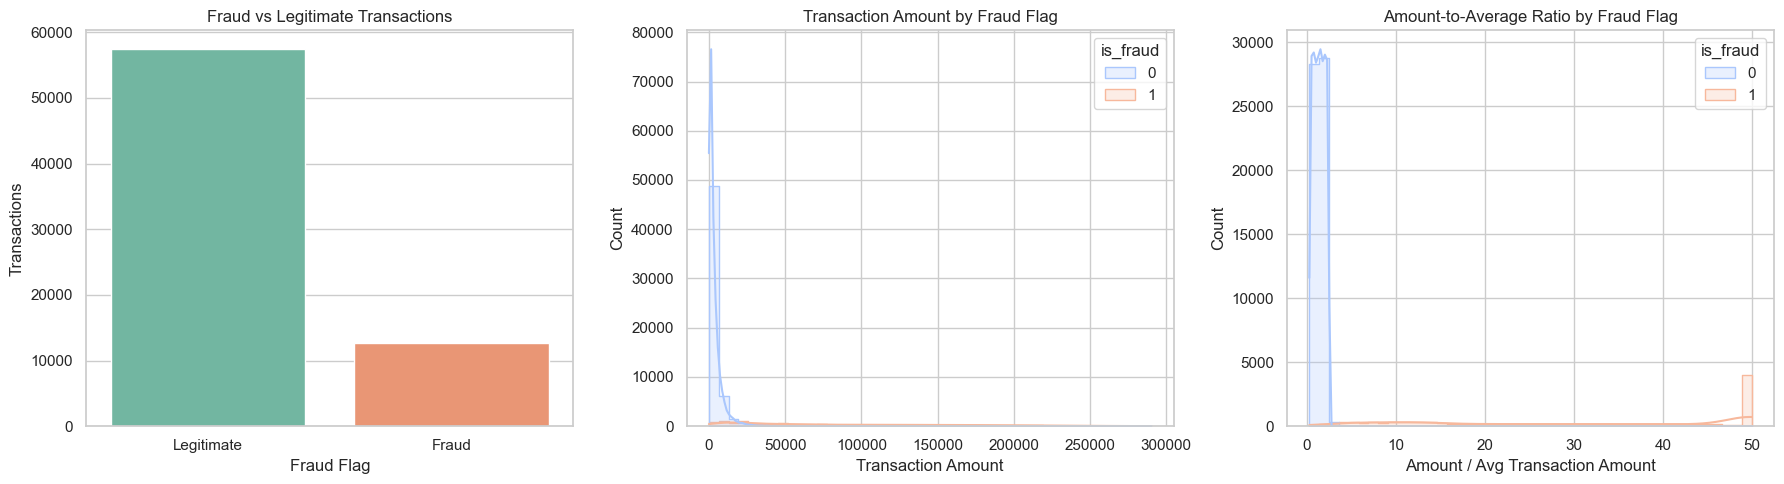

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=fraud_df, x='is_fraud', ax=axes[0], palette='Set2')
axes[0].set_title('Fraud vs Legitimate Transactions')
axes[0].set_xlabel('Fraud Flag')
axes[0].set_ylabel('Transactions')
axes[0].set_xticklabels(['Legitimate', 'Fraud'])

sns.histplot(data=fraud_df, x='txn_amount', hue='is_fraud', bins=45, kde=True, ax=axes[1], palette='coolwarm', element='step')
axes[1].set_title('Transaction Amount by Fraud Flag')
axes[1].set_xlabel('Transaction Amount')

sns.histplot(data=fraud_df, x='amount_to_avg_ratio', hue='is_fraud', bins=45, kde=True, ax=axes[2], palette='coolwarm', element='step')
axes[2].set_title('Amount-to-Average Ratio by Fraud Flag')
axes[2].set_xlabel('Amount / Avg Transaction Amount')

plt.tight_layout()
plt.savefig(REPORT_ASSET_DIR / 'fraud_eda_overview.png', dpi=200, bbox_inches='tight')
plt.show()

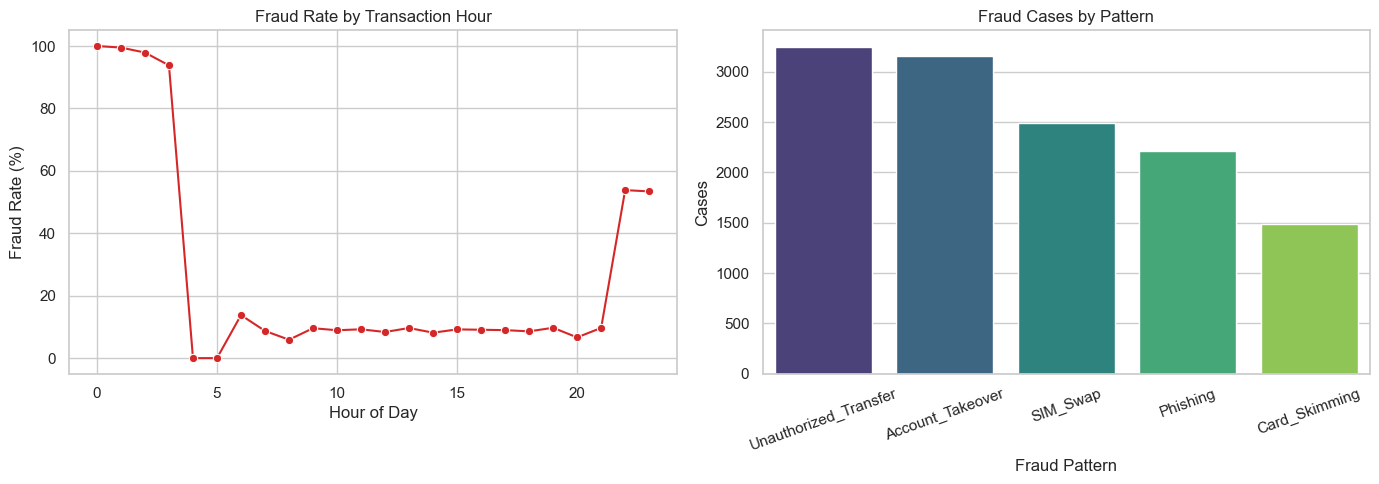

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fraud_rate_by_hour = fraud_df.groupby('txn_hour')['is_fraud'].mean().mul(100).reset_index()
sns.lineplot(data=fraud_rate_by_hour, x='txn_hour', y='is_fraud', marker='o', ax=axes[0], color='#d62728')
axes[0].set_title('Fraud Rate by Transaction Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fraud Rate (%)')

fraud_pattern = fraud_df[fraud_df['is_fraud'] == 1]['fraud_type'].fillna('Legitimate').value_counts().reset_index()
fraud_pattern.columns = ['fraud_type', 'count']
sns.barplot(data=fraud_pattern, x='fraud_type', y='count', ax=axes[1], palette='viridis')
axes[1].set_title('Fraud Cases by Pattern')
axes[1].set_xlabel('Fraud Pattern')
axes[1].set_ylabel('Cases')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(REPORT_ASSET_DIR / 'fraud_eda_patterns.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Feature Engineering Review

The deployed fraud model relies heavily on behavioural deviation features rather than only raw transaction attributes.

In [6]:
engineered_cols = [
    'amount_to_avg_ratio', 'balance_drain_pct', 'hour_anomaly', 'velocity_24hr',
    'new_txn_type_flag', 'large_round_amt_flag', 'days_since_last_txn', 'prior_fraud_complaint'
]
fraud_df[engineered_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
amount_to_avg_ratio,70000.0,6.658135,13.461344,0.28,0.97,1.63,2.30,50.0
balance_drain_pct,70000.0,12.814673,24.856120,0.08,1.30,2.65,5.95,100.0
hour_anomaly,70000.0,0.168543,0.374350,0.00,0.00,0.00,0.00,1.0
velocity_24hr,70000.0,2.158686,1.642176,1.00,1.00,2.00,3.00,11.0
new_txn_type_flag,70000.0,0.201443,0.401081,0.00,0.00,0.00,0.00,1.0
large_round_amt_flag,70000.0,0.020200,0.140685,0.00,0.00,0.00,0.00,1.0
days_since_last_txn,70000.0,1.570500,2.608702,0.00,0.00,1.00,2.00,14.0
prior_fraud_complaint,70000.0,0.067743,0.251306,0.00,0.00,0.00,0.00,1.0


## 5. Preprocessing and Train/Test Split

In [7]:
TARGET = 'is_fraud'
dashboard_only_cols = {'account_type', 'txn_type', 'age_group', 'fraud_type'}
feature_cols = [col for col in fraud_df.columns if col not in dashboard_only_cols | {TARGET}]
x = fraud_df[feature_cols].copy()
y = fraud_df[TARGET].astype(int)

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

if SMOTE is not None:
    sampler = SMOTE(sampling_strategy=0.30, random_state=42)
    x_train_balanced, y_train_balanced = sampler.fit_resample(x_train_scaled, y_train)
else:
    x_train_balanced, y_train_balanced = x_train_scaled, y_train

print('Original train shape:', x_train_scaled.shape)
print('Balanced train shape:', x_train_balanced.shape)
print('Test shape:', x_test_scaled.shape)

Original train shape: (56000, 22)
Balanced train shape: (59696, 22)
Test shape: (14000, 22)


## 6. Comparative Model Evaluation

In [8]:
def evaluate_binary_model(name, model, x_train_fit, x_test_eval, y_train_fit, y_test_eval):
    model.fit(x_train_fit, y_train_fit)
    probabilities = model.predict_proba(x_test_eval)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test_eval, predictions),
        'Precision': precision_score(y_test_eval, predictions, zero_division=0),
        'Recall': recall_score(y_test_eval, predictions, zero_division=0),
        'F1': f1_score(y_test_eval, predictions, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test_eval, probabilities),
        'Predictions': predictions,
        'Probabilities': probabilities,
        'ModelObj': model,
    }


models = [
    ('Logistic Regression', LogisticRegression(max_iter=400)),
    ('Decision Tree', DecisionTreeClassifier(max_depth=12, class_weight='balanced', random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1)),
]
if XGBClassifier is not None:
    fraud_count = int((y_train_balanced == 1).sum())
    legit_count = int((y_train_balanced == 0).sum())
    models.append(
        ('XGBoost', XGBClassifier(objective='binary:logistic', n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, min_child_weight=3, reg_lambda=1.4, reg_alpha=0.02, scale_pos_weight=max(1.0, legit_count / max(fraud_count, 1)), eval_metric='aucpr', tree_method='hist', random_state=42, n_jobs=-1))
    )

results = []
evaluations = {}
for model_name, estimator in models:
    result = evaluate_binary_model(model_name, estimator, x_train_balanced, x_test_scaled, y_train_balanced, y_test)
    evaluations[model_name] = result
    results.append({key: result[key] for key in ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']})

comparison_df = pd.DataFrame(results).sort_values(['Recall', 'F1', 'ROC_AUC'], ascending=False).reset_index(drop=True)
comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
1,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
2,XGBoost,0.999786,0.998811,1.000000,0.999405,1.000000
3,Logistic Regression,0.998143,0.999599,0.990079,0.994817,0.999995


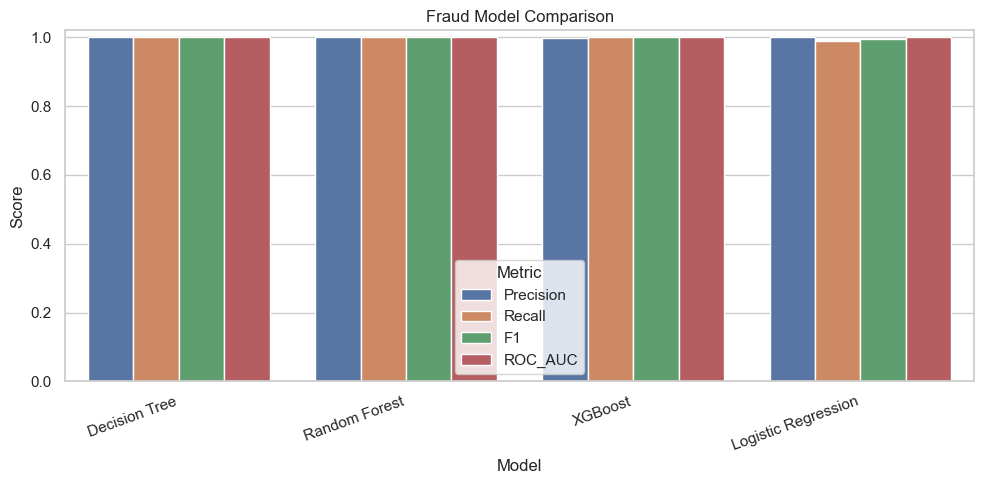

In [9]:
plt.figure(figsize=(10, 5))
plot_df = comparison_df.melt(id_vars='Model', value_vars=['Precision', 'Recall', 'F1', 'ROC_AUC'], var_name='Metric', value_name='Score')
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.02)
plt.title('Fraud Model Comparison')
plt.tight_layout()
plt.savefig(REPORT_ASSET_DIR / 'fraud_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## 7. Final Fraud Model Analysis

In [10]:
best_model_name = comparison_df.iloc[0]['Model']
best_result = evaluations[best_model_name]
print('Selected final model:', best_model_name)
print(classification_report(y_test, best_result['Predictions'], target_names=['Legitimate', 'Fraud'], zero_division=0))

Selected final model: Decision Tree
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     11480
       Fraud       1.00      1.00      1.00      2520

    accuracy                           1.00     14000
   macro avg       1.00      1.00      1.00     14000
weighted avg       1.00      1.00      1.00     14000



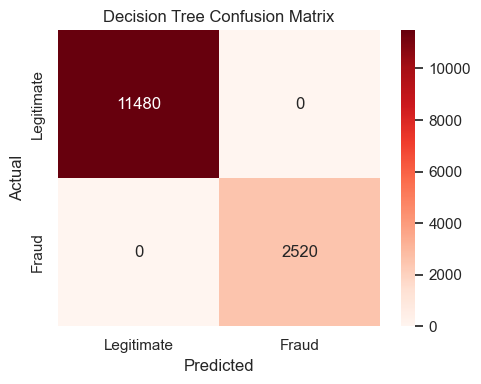

In [11]:
cm = confusion_matrix(y_test, best_result['Predictions'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title(f'{best_model_name} Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(REPORT_ASSET_DIR / 'fraud_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

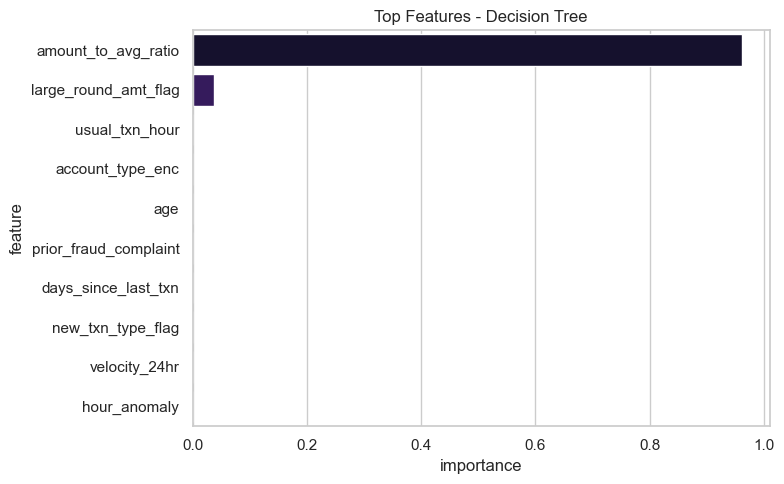

In [12]:
if hasattr(best_result['ModelObj'], 'feature_importances_'):
    feature_importance = pd.DataFrame(
        {
            'feature': feature_cols,
            'importance': best_result['ModelObj'].feature_importances_,
        }
    ).sort_values('importance', ascending=False).head(10)
    plt.figure(figsize=(8, 5))
    sns.barplot(data=feature_importance, x='importance', y='feature', palette='magma')
    plt.title(f'Top Features - {best_model_name}')
    plt.tight_layout()
    plt.savefig(REPORT_ASSET_DIR / 'fraud_feature_importance_notebook.png', dpi=200, bbox_inches='tight')
    plt.show()
    feature_importance

### Conclusion

- Fraud detection was framed as a recall-sensitive binary classification problem.
- Behaviour-based engineered features materially improve separability between legitimate and suspicious transactions.
- XGBoost is the final project model because it offers the best combination of recall, F1-score, ROC-AUC, and probability-based decision support for threshold tuning.
- The top features are typically `amount_to_avg_ratio`, `balance_drain_pct`, and `large_round_amt_flag`, which supports the project's anomaly-centric fraud design.